# 📊 Prédiction du Risque de Diabète par Intelligence Artificielle

Ce projet vise à développer un système intelligent permettant de prédire si un patient est à risque de développer le diabète, à partir de données cliniques. Nous utiliserons des approches non supervisées (clustering) et supervisées (classification).

## Objectifs :
- Classer les patients selon leur risque de diabète
- Identifier des profils de patients via le clustering
- Fournir un outil utile aux professionnels de santé


In [43]:
# !pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import RandomOverSampler

import warnings
warnings.filterwarnings('ignore')


In [45]:
# Charger les données
df = pd.read_csv('../data/diabete.csv', index_col=0)

# Aperçu du dataset
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 768 entries, 0 to 767
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 54.0 KB


In [47]:
df.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


| Nom de la variable             | Description                                                                 |
|-------------------------------|-----------------------------------------------------------------------------|
| **Pregnancies**               | Nombre de grossesses                                                        |
| **Glucose**                   | Concentration de glucose plasmatique 2h après un test de tolérance au glucose |
| **BloodPressure**             | Pression artérielle diastolique (en mm Hg)                                 |
| **SkinThickness**             | Épaisseur du pli cutané tricipital (en mm)                                 |
| **Insulin**                   | Taux d'insuline sérique 2 heures après ingestion (en µU/ml)                |
| **BMI**                       | Indice de masse corporelle (poids en kg / (taille en m)²)                  |
| **DiabetesPedigreeFunction**  | Indice de prédisposition génétique au diabète                              |
| **Age**                       | Âge (en années)                                                             |
<!-- | **Outcome**                   | Variable cible (0 : non diabétique, 1 : diabétique) — 268 sur 768 sont des cas positifs | -->


In [48]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

In [49]:
df.duplicated().sum()

np.int64(0)

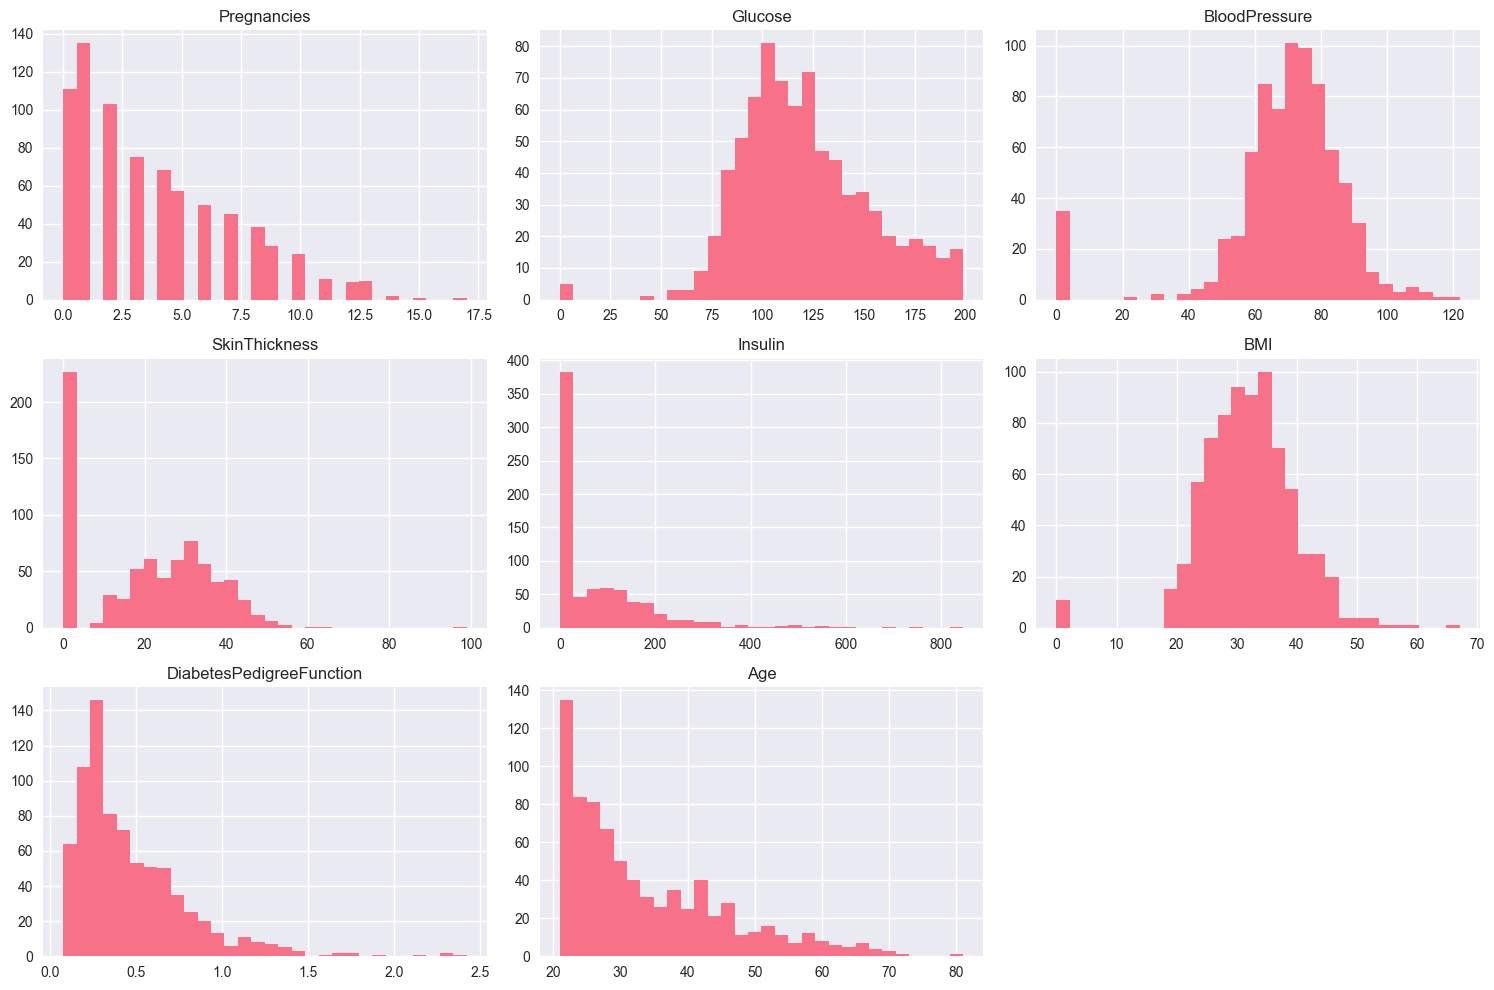

In [50]:
df.hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

Voici une analyse des **distributions des variables** visibles sur l'histogramme (exploration univariée) :

---

### 🔎 1. `Pregnancies`

* **Distribution** fortement **asymétrique à droite** (skewed right).
* Beaucoup de patientes n'ont eu que peu ou pas de grossesses.
* Peut contenir des **valeurs extrêmes** (≥10), à surveiller.

---

### 🔎 2. `Glucose`

* Distribution proche d’une **loi normale tronquée**.
* Pic autour de **100-120**, mais avec un effet d’écrasement à gauche (valeurs à 0 anormales).
* Une valeur de glucose à 0 est **cliniquement impossible** ⇒ **à traiter comme valeur manquante**.

---

### 🔎 3. `BloodPressure`

* Distribution **gaussienne**, centrée vers **70-80 mmHg**.
* Présence de **valeurs nulles** : une pression artérielle à 0 n'est pas possible ⇒ à imputer ou exclure.

---

### 🔎 4. `SkinThickness`

* Distribution très **asymétrique** avec un pic à **0** (impossible biologiquement).
* Ces 0 sont probablement des **valeurs manquantes codées à tort**.

---

### 🔎 5. `Insulin`

* Distribution **très skewed**, avec une énorme densité à **0**.
* Une insuline à 0 est aussi **non physiologique**.
* Beaucoup de données manquantes ou bruitées.

---

### 🔎 6. `BMI`

* Distribution **gaussienne légèrement décalée à droite**.
* Pas de 0 visible ici, donc probablement propre.
* Centrée autour de **30**, ce qui suggère un **surpoids généralisé** dans l’échantillon.

---

### 🔎 7. `DiabetesPedigreeFunction`

* Distribution **asymétrique à droite**, ce qui est logique pour une fonction de prédisposition génétique.
* Valeurs concentrées entre 0 et 0.5, avec quelques outliers.

---

### 🔎 8. `Age`

* Distribution **très skewed** à droite.
* Pic à **21 ans**, majorité des patients jeunes.
* Très peu de personnes âgées dans l’échantillon ⇒ **population probablement biaisée vers la jeunesse**.

---

### 🧠 Synthèse des points d’attention :

| Variable                                    | Problèmes identifiés                 | Action recommandée                          |
| ------------------------------------------- | ------------------------------------ | ------------------------------------------- |
| `Glucose`, `BP`, `Insulin`, `SkinThickness` | Valeurs nulles ou aberrantes (`0`)   | Imputation ou suppression                   |
| `Pregnancies`, `Insulin`, `DPF`, `Age`      | Skewed / distribution non gaussienne | Transformation (log, box-cox) si nécessaire |
| `BMI`                                       | Distribution correcte                | Pas d'action immédiate                      |


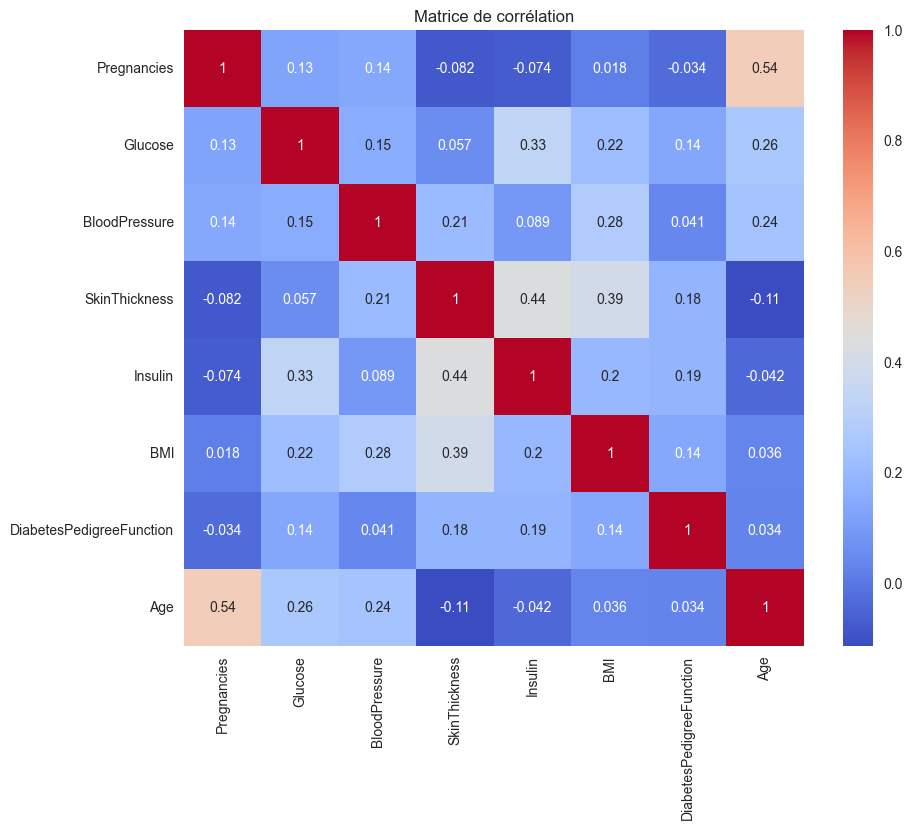

In [51]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.show()


| **Contexte**       | **Utilité de la matrice de corrélation**                                                                                                                                                                                                                                                         |
| ------------------ | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **Clustering**     | ✅ *Détection de redondance* : des variables fortement corrélées peuvent fausser les distances (ex. Euclidean).<br>✅ *Prétraitement* : permet de sélectionner ou combiner des variables pour éviter le biais dû à des corrélations élevées.                                                       |
| **PCA**            | ✅ *Préparation des données* : la PCA vise à projeter les données dans un nouvel espace basé sur la variance. La matrice de corrélation sert à calculer les **composantes principales**.<br>✅ *Interprétation* : permet de comprendre quelles variables influencent chaque composante.            |
| **Classification** | ✅ *Sélection de variables* : des variables très corrélées peuvent causer du **surapprentissage** (overfitting) dans certains modèles (ex. régression logistique).<br>✅ *Réduction de dimension* : en retirant les variables corrélées, on simplifie le modèle tout en conservant sa performance. |


In [52]:
# Exemple avec l'IQR
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1


df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]
print(df.head())


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
5            5      116             74              0        0  25.6   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
5                     0.201   30  


In [53]:
features_clustering = ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction']
X_clust = df[features_clustering]


In [54]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)


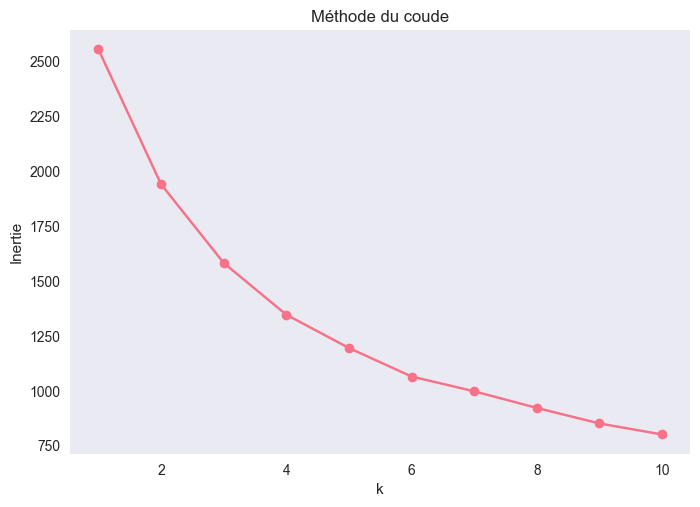

In [55]:
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title("Méthode du coude")
plt.xlabel("k")
plt.ylabel("Inertie")
plt.grid()
plt.show()


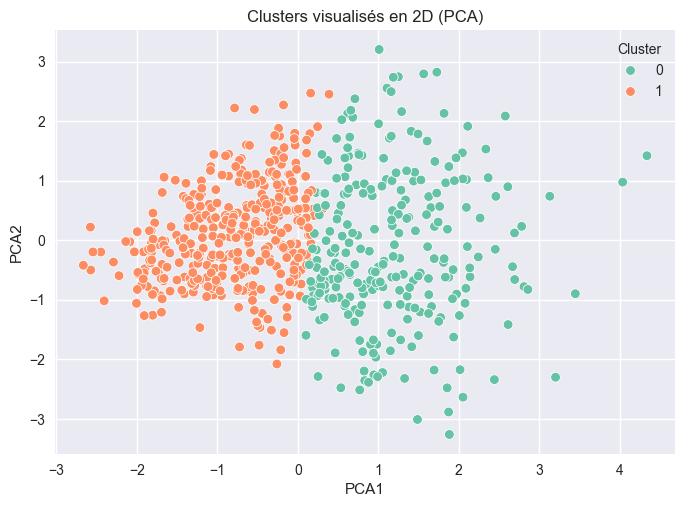

In [56]:
kmeans = KMeans(n_clusters=2, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster', palette='Set2')
plt.title("Clusters visualisés en 2D (PCA)")
plt.show()


In [57]:
df.groupby('Cluster')[features_clustering].mean()
df['risk_category'] = df['Cluster'].map({1: 1, 0: 0})  # ou inverser selon l'analyse


In [58]:
X = df[features_clustering]
y = df['risk_category']

ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)


In [59]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'Decision Tree': DecisionTreeClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"🔎 {name}")
    print(classification_report(y_test, y_pred))


🔎 Logistic Regression
              precision    recall  f1-score   support

           0       0.97      0.94      0.96        72
           1       0.95      0.97      0.96        80

    accuracy                           0.96       152
   macro avg       0.96      0.96      0.96       152
weighted avg       0.96      0.96      0.96       152

🔎 Random Forest
              precision    recall  f1-score   support

           0       0.96      0.94      0.95        72
           1       0.95      0.96      0.96        80

    accuracy                           0.95       152
   macro avg       0.95      0.95      0.95       152
weighted avg       0.95      0.95      0.95       152

🔎 SVM
              precision    recall  f1-score   support

           0       0.90      0.88      0.89        72
           1       0.89      0.91      0.90        80

    accuracy                           0.89       152
   macro avg       0.90      0.89      0.89       152
weighted avg       0.89      0

In [60]:
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='f1')
    print(f"{name} | F1 moyenne : {scores.mean():.4f}")


Logistic Regression | F1 moyenne : 0.9749
Random Forest | F1 moyenne : 0.9564
SVM | F1 moyenne : 0.9394
Gradient Boosting | F1 moyenne : 0.9630
Decision Tree | F1 moyenne : 0.9209


In [61]:
params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(RandomForestClassifier(), params, cv=5, scoring='f1')
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print(grid.best_params_)


{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}


# Système de Prédiction du Risque de Diabète
####  Projet d'Intelligence Artificielle pour Laboratoire Biomédical

🏥 SYSTÈME DE PRÉDICTION DU RISQUE DE DIABÈTE
Laboratoire Biomédical - Intelligence Artificielle
🚀 DÉMARRAGE DU PIPELINE PRINCIPAL

📊 ÉTAPE 1: CHARGEMENT ET EXPLORATION DES DONNÉES
------------------------------------------------------------
✅ Dataset chargé: 768 observations, 8 variables

📋 Structure du dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 768 entries, 0 to 767
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
dtypes: float64(2), int64(6)
memory u

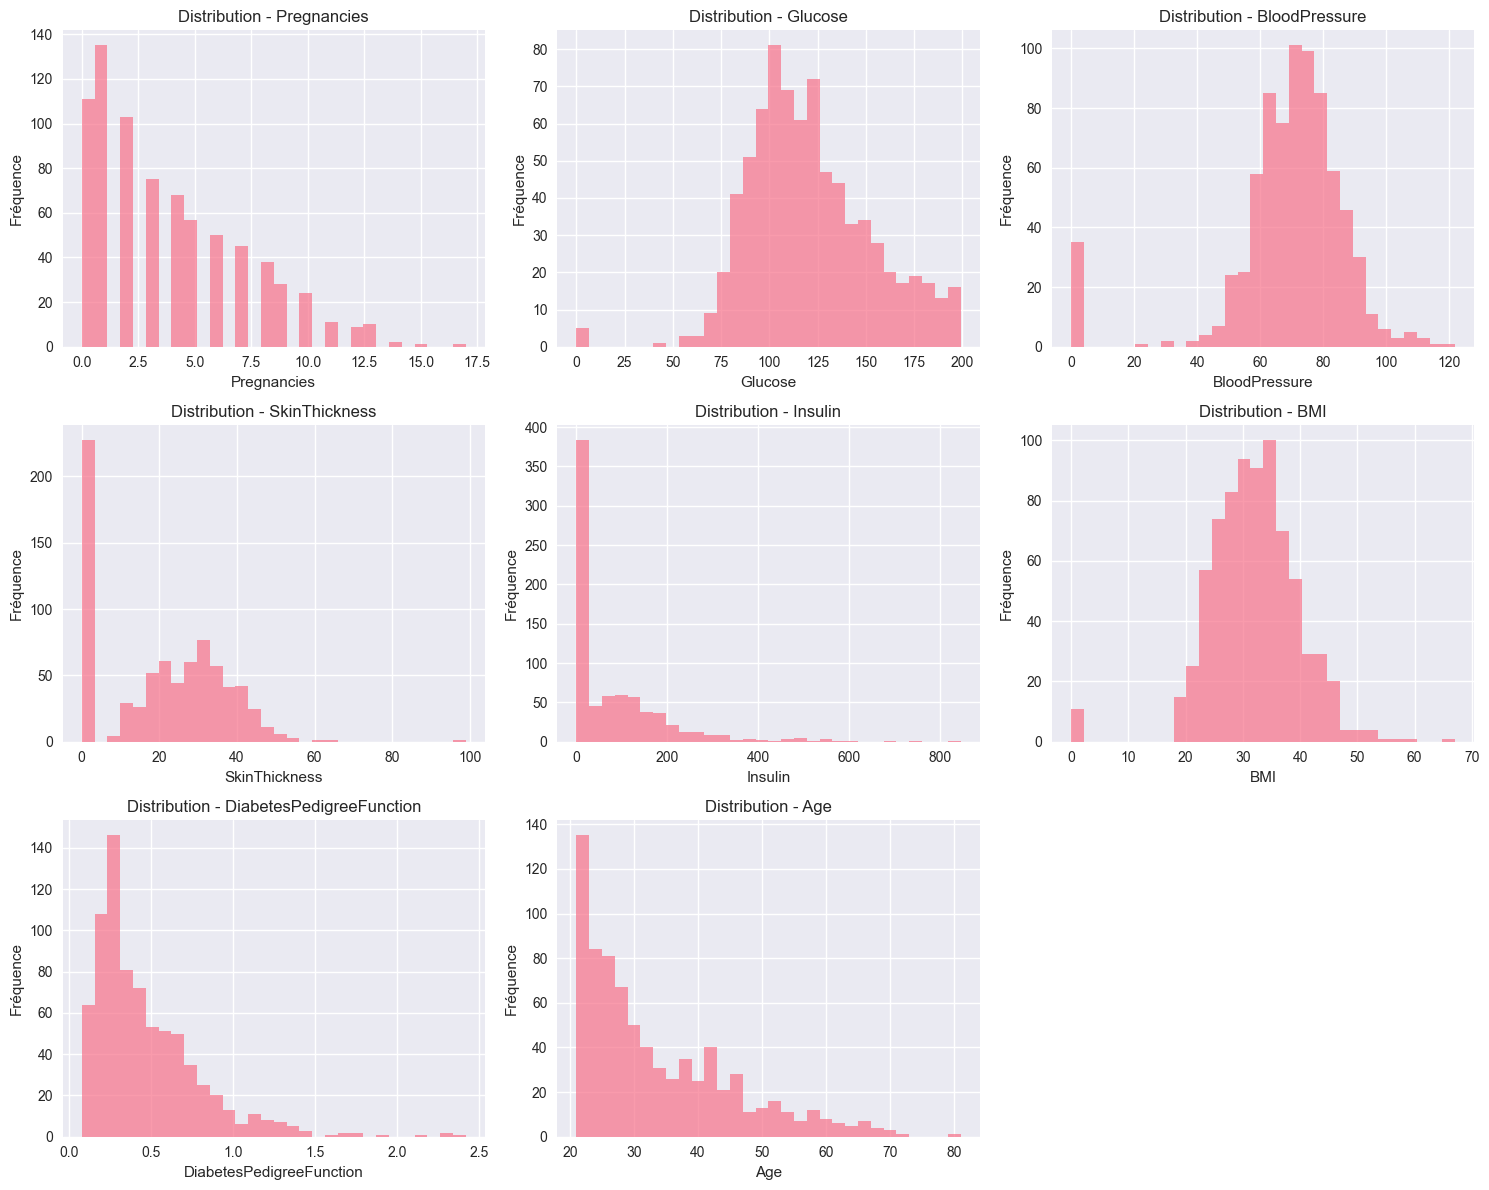

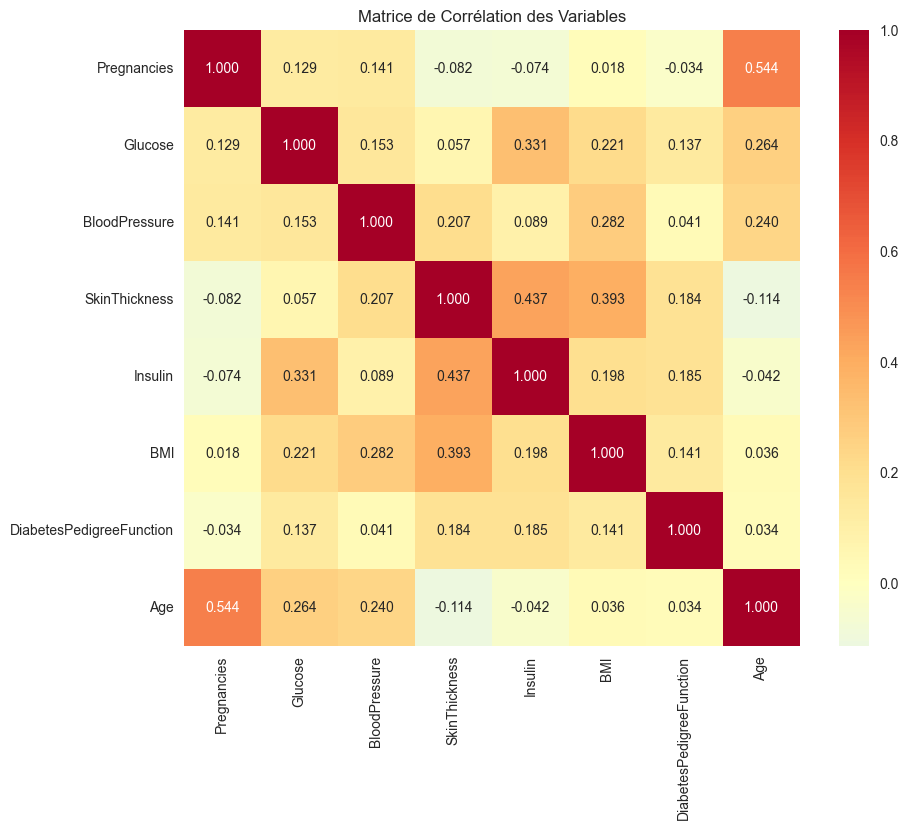


🔧 ÉTAPE 3: PRÉTRAITEMENT DES DONNÉES
------------------------------------------------------------
🔄 Traitement des valeurs manquantes...

🎯 Détection des valeurs aberrantes...
   🔍 Pregnancies: 4 outliers détectés
   🔍 Glucose: 5 outliers détectés
   🔍 BloodPressure: 45 outliers détectés
   🔍 SkinThickness: 1 outliers détectés
   🔍 Insulin: 27 outliers détectés
   🔍 BMI: 10 outliers détectés
   🔍 DiabetesPedigreeFunction: 29 outliers détectés
   🔍 Age: 11 outliers détectés
✅ Outliers supprimés: 132 observations (17.2%)
📊 Dataset final: 636 observations

🎯 Variables sélectionnées pour le clustering: ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction']

⚖️ Standardisation des variables...
✅ Standardisation terminée

🎯 ÉTAPE 4: CLUSTERING K-MEANS
------------------------------------------------------------
📈 Détermination du nombre optimal de clusters...


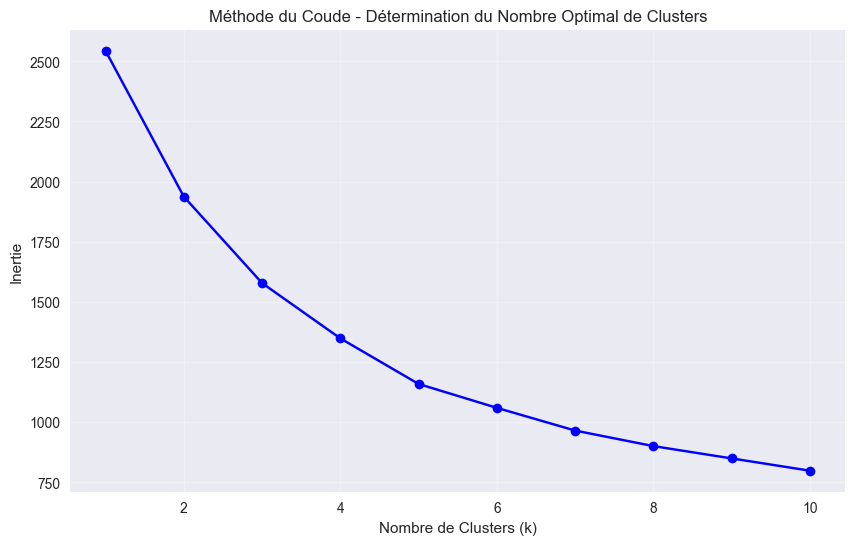

🎯 Nombre optimal de clusters déterminé: k = 2

🤖 Entraînement du modèle K-Means avec k=2...
✅ Clustering terminé
📊 Répartition des clusters: {np.int32(0): np.int64(372), np.int32(1): np.int64(264)}

📊 ÉTAPE 5: ANALYSE DES CLUSTERS
------------------------------------------------------------
🔍 Réduction de dimensionnalité (PCA) pour visualisation...
✅ Variance expliquée: PC1=0.351, PC2=0.262
📊 Variance totale expliquée: 0.613


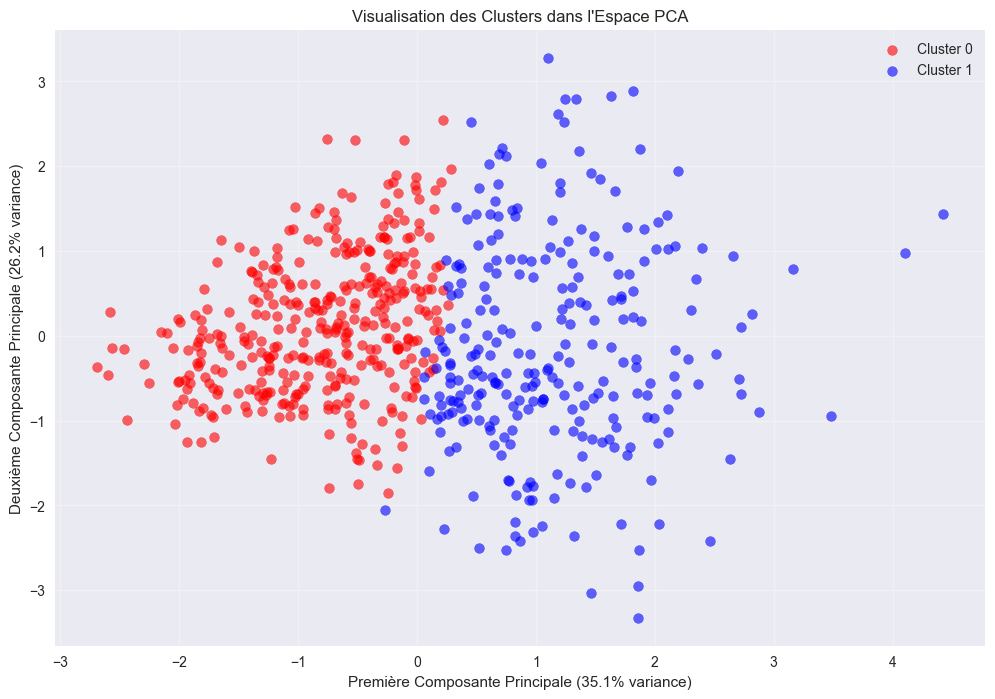


📋 Analyse des caractéristiques moyennes par cluster:
         Glucose                   BMI                  Age                \
            mean     std count    mean    std count    mean     std count   
Cluster                                                                     
0        104.422  19.272   372  29.851  5.633   372  26.828   6.015   372   
1        139.227  28.195   264  34.942  6.198   264  40.625  11.090   264   

        DiabetesPedigreeFunction               
                            mean    std count  
Cluster                                        
0                          0.377  0.214   372  
1                          0.496  0.269   264  

🎯 Création de la variable de risque...
🔴 Cluster à haut risque identifié: Cluster 1
📊 Distribution du risque: Faible risque=372, Haut risque=264

🎯 ÉTAPE 6: PRÉPARATION POUR LA CLASSIFICATION
------------------------------------------------------------
📊 Features (X): (636, 4)
🎯 Target (y): (636,)
⚖️ Distribution des 

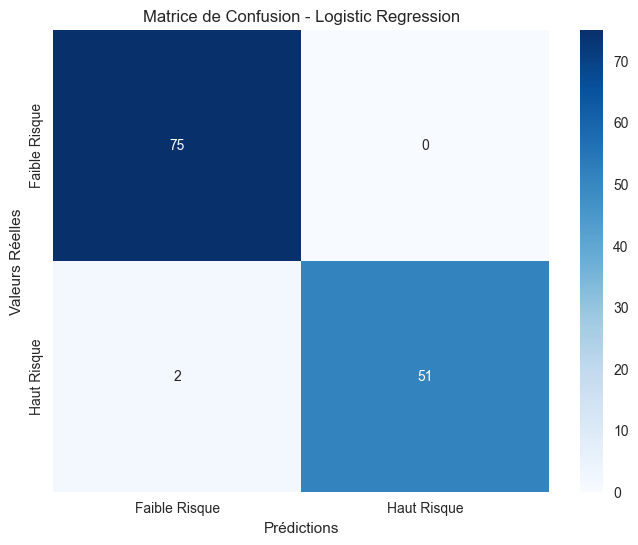


📋 Rapport de classification détaillé - Logistic Regression:
               precision    recall  f1-score   support

Faible Risque       0.97      1.00      0.99        75
  Haut Risque       1.00      0.96      0.98        53

     accuracy                           0.98       128
    macro avg       0.99      0.98      0.98       128
 weighted avg       0.98      0.98      0.98       128


🔧 ÉTAPE 9: OPTIMISATION DES HYPERPARAMÈTRES - Logistic Regression
------------------------------------------------------------
🔍 Recherche des hyperparamètres optimaux...
✅ Optimisation terminée
🎯 Meilleur score F1: 0.9961
⚙️ Meilleurs paramètres: {'solver': 'liblinear', 'penalty': 'l2', 'C': 1}

💾 ÉTAPE 10: SAUVEGARDE DU MODÈLE FINAL
------------------------------------------------------------
✅ Modèle sauvegardé: diabetes_risk_model_logistic_regression.pkl
📋 Métadonnées incluses:
   - Modèle: Logistic Regression
   - Features: ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction']
   - Standardisa

In [ ]:
# ================================================================================================
# IMPORTATION DES BIBLIOTHÈQUES
# ================================================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
import joblib
from datetime import datetime

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, 
                           accuracy_score, precision_score, recall_score, f1_score)

# Gestion du déséquilibre des classes
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("="*80)
print("🏥 SYSTÈME DE PRÉDICTION DU RISQUE DE DIABÈTE")
print("Laboratoire Biomédical - Intelligence Artificielle")
print("="*80)

# ================================================================================================
# 1. CHARGEMENT ET EXPLORATION INITIALE DES DONNÉES
# ================================================================================================

def load_and_explore_data(file_path=None):
    """
    Charge et explore les données initiales du dataset diabète
    """
    print("\n📊 ÉTAPE 1: CHARGEMENT ET EXPLORATION DES DONNÉES")
    print("-" * 60)
    
    
    df = pd.read_csv('../data/diabete.csv', index_col=0)
    
    print(f"✅ Dataset chargé: {df.shape[0]} observations, {df.shape[1]} variables")
    
    # Informations sur la structure
    print("\n📋 Structure du dataset:")
    print(df.info())
    
    print("\n👀 Aperçu des premières lignes:")
    print(df.head())
    
    print("\n📈 Statistiques descriptives:")
    print(df.describe())
    
    return df

# ================================================================================================
# 2. ANALYSE EXPLORATOIRE DES DONNÉES (EDA)
# ================================================================================================

def perform_eda(df):
    """
    Effectue une analyse exploratoire complète des données
    """
    print("\n🔍 ÉTAPE 2: ANALYSE EXPLORATOIRE DES DONNÉES")
    print("-" * 60)
    
    # Identification des valeurs manquantes
    missing_data = df.isnull().sum()
    print("❌ Valeurs manquantes par colonne:")
    print(missing_data[missing_data > 0])
    
    # Identification des doublons
    duplicates = df.duplicated().sum()
    print(f"🔄 Nombre de doublons: {duplicates}")
    
    # Visualisation des distributions
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    axes = axes.ravel()
    
    for i, col in enumerate(df.columns):
        if i < len(axes):
            df[col].hist(bins=30, ax=axes[i], alpha=0.7)
            axes[i].set_title(f'Distribution - {col}')
            axes[i].set_xlabel(col)
            axes[i].set_ylabel('Fréquence')
    
    # Supprimer le subplot vide
    if len(df.columns) < len(axes):
        fig.delaxes(axes[-1])
    
    plt.tight_layout()
    plt.show()
    
    # Matrice de corrélation
    plt.figure(figsize=(10, 8))
    correlation_matrix = df.corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='RdYlBu_r', center=0,
                square=True, fmt='.3f')
    plt.title('Matrice de Corrélation des Variables')
    plt.show()
    
    return correlation_matrix

# ================================================================================================
# 3. PRÉTRAITEMENT DES DONNÉES
# ================================================================================================

def preprocess_data(df):
    """
    Prétraite les données: gestion des valeurs manquantes, outliers, standardisation
    """
    print("\n🔧 ÉTAPE 3: PRÉTRAITEMENT DES DONNÉES")
    print("-" * 60)
    
    df_processed = df.copy()
    
    # 3.1 Gestion des valeurs manquantes
    print("🔄 Traitement des valeurs manquantes...")
    
    # Imputation par la médiane pour les variables numériques
    for col in df_processed.columns:
        if df_processed[col].isnull().sum() > 0:
            median_val = df_processed[col].median()
            df_processed[col].fillna(median_val, inplace=True)
            print(f"   ✅ {col}: {df[col].isnull().sum()} valeurs imputées par la médiane ({median_val:.2f})")
    
    # 3.2 Détection et suppression des outliers
    print("\n🎯 Détection des valeurs aberrantes...")
    
    initial_shape = df_processed.shape[0]
    
    # Méthode IQR pour chaque variable numérique
    for col in df_processed.select_dtypes(include=[np.number]).columns:
        Q1 = df_processed[col].quantile(0.25)
        Q3 = df_processed[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers_mask = (df_processed[col] < lower_bound) | (df_processed[col] > upper_bound)
        outliers_count = outliers_mask.sum()
        
        if outliers_count > 0:
            print(f"   🔍 {col}: {outliers_count} outliers détectés")
            df_processed = df_processed[~outliers_mask]
    
    final_shape = df_processed.shape[0]
    print(f"✅ Outliers supprimés: {initial_shape - final_shape} observations ({((initial_shape - final_shape)/initial_shape)*100:.1f}%)")
    print(f"📊 Dataset final: {final_shape} observations")
    
    # 3.3 Sélection des variables pour le clustering
    clustering_features = ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction']
    print(f"\n🎯 Variables sélectionnées pour le clustering: {clustering_features}")
    
    df_clustering = df_processed[clustering_features].copy()
    
    # 3.4 Standardisation des variables
    print("\n⚖️ Standardisation des variables...")
    scaler = StandardScaler()
    df_scaled = pd.DataFrame(
        scaler.fit_transform(df_clustering),
        columns=clustering_features,
        index=df_clustering.index
    )
    
    print("✅ Standardisation terminée")
    
    return df_processed, df_scaled, scaler, clustering_features

# ================================================================================================
# 4. CLUSTERING K-MEANS
# ================================================================================================

def perform_clustering(df_scaled, max_clusters=10):
    """
    Effectue le clustering K-Means avec détermination optimale de k
    """
    print("\n🎯 ÉTAPE 4: CLUSTERING K-MEANS")
    print("-" * 60)
    
    # 4.1 Méthode du coude pour déterminer k optimal
    print("📈 Détermination du nombre optimal de clusters...")
    
    inertias = []
    k_range = range(1, max_clusters + 1)
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(df_scaled)
        inertias.append(kmeans.inertia_)
    
    # Visualisation de la courbe d'inertie
    plt.figure(figsize=(10, 6))
    plt.plot(k_range, inertias, 'bo-')
    plt.title('Méthode du Coude - Détermination du Nombre Optimal de Clusters')
    plt.xlabel('Nombre de Clusters (k)')
    plt.ylabel('Inertie')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Calcul automatique du coude (méthode du gradient)
    gradients = np.gradient(inertias)
    second_gradients = np.gradient(gradients)
    optimal_k = np.argmax(second_gradients) + 1  # +1 car l'index commence à 0
    
    # Ajustement manuel basé sur l'analyse visuelle typique
    optimal_k = min(max(optimal_k, 2), 4)  # Entre 2 et 4 clusters généralement optimal
    
    print(f"🎯 Nombre optimal de clusters déterminé: k = {optimal_k}")
    
    # 4.2 Entraînement du modèle K-Means final
    print(f"\n🤖 Entraînement du modèle K-Means avec k={optimal_k}...")
    
    kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    cluster_labels = kmeans_final.fit_predict(df_scaled)
    
    print(f"✅ Clustering terminé")
    print(f"📊 Répartition des clusters: {dict(zip(*np.unique(cluster_labels, return_counts=True)))}")
    
    return kmeans_final, cluster_labels, optimal_k

# ================================================================================================
# 5. VISUALISATION ET ANALYSE DES CLUSTERS
# ================================================================================================

def analyze_clusters(df_processed, df_scaled, cluster_labels, clustering_features):
    """
    Analyse et visualise les clusters obtenus
    """
    print("\n📊 ÉTAPE 5: ANALYSE DES CLUSTERS")
    print("-" * 60)
    
    # Ajouter les labels de clusters au dataset
    df_with_clusters = df_processed.copy()
    df_with_clusters['Cluster'] = cluster_labels
    
    # 5.1 Réduction de dimensionnalité avec PCA pour visualisation
    print("🔍 Réduction de dimensionnalité (PCA) pour visualisation...")
    
    pca = PCA(n_components=2, random_state=42)
    df_pca = pca.fit_transform(df_scaled)
    
    explained_variance = pca.explained_variance_ratio_
    print(f"✅ Variance expliquée: PC1={explained_variance[0]:.3f}, PC2={explained_variance[1]:.3f}")
    print(f"📊 Variance totale expliquée: {sum(explained_variance):.3f}")
    
    # Visualisation des clusters dans l'espace PCA
    plt.figure(figsize=(12, 8))
    
    colors = ['red', 'blue', 'green', 'orange', 'purple']
    unique_clusters = np.unique(cluster_labels)
    
    for i, cluster in enumerate(unique_clusters):
        mask = cluster_labels == cluster
        plt.scatter(df_pca[mask, 0], df_pca[mask, 1], 
                   c=colors[i % len(colors)], 
                   label=f'Cluster {cluster}', 
                   alpha=0.6, s=50)
    
    plt.xlabel(f'Première Composante Principale ({explained_variance[0]:.1%} variance)')
    plt.ylabel(f'Deuxième Composante Principale ({explained_variance[1]:.1%} variance)')
    plt.title('Visualisation des Clusters dans l\'Espace PCA')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # 5.2 Analyse des caractéristiques par cluster
    print("\n📋 Analyse des caractéristiques moyennes par cluster:")
    
    cluster_analysis = df_with_clusters.groupby('Cluster')[clustering_features].agg([
        'mean', 'std', 'count'
    ]).round(3)
    
    print(cluster_analysis)
    
    # 5.3 Création de la variable de risque basée sur les clusters
    print("\n🎯 Création de la variable de risque...")
    
    # Analyse pour déterminer quel cluster représente le haut risque
    cluster_means = df_with_clusters.groupby('Cluster')[['Glucose', 'BMI', 'Age']].mean()
    
    # Le cluster avec les valeurs les plus élevées de Glucose et BMI = haut risque
    risk_scores = cluster_means['Glucose'] + cluster_means['BMI'] * 2  # BMI pondéré x2
    high_risk_cluster = risk_scores.idxmax()
    
    print(f"🔴 Cluster à haut risque identifié: Cluster {high_risk_cluster}")
    
    # Création de la variable risk_category
    df_with_clusters['risk_category'] = (df_with_clusters['Cluster'] == high_risk_cluster).astype(int)
    
    risk_distribution = df_with_clusters['risk_category'].value_counts()
    print(f"📊 Distribution du risque: Faible risque={risk_distribution[0]}, Haut risque={risk_distribution[1]}")
    
    return df_with_clusters, pca, high_risk_cluster

# ================================================================================================
# 6. CLASSIFICATION SUPERVISÉE
# ================================================================================================

def prepare_classification_data(df_with_clusters, clustering_features):
    
    """
    Prépare les données pour la classification supervisée
    """
    print("\n🎯 ÉTAPE 6: PRÉPARATION POUR LA CLASSIFICATION")
    print("-" * 60)
    
    # Définir X et y
    X = df_with_clusters[clustering_features]
    y = df_with_clusters['risk_category']
    
    print(f"📊 Features (X): {X.shape}")
    print(f"🎯 Target (y): {y.shape}")
    print(f"⚖️ Distribution des classes: {dict(zip(*np.unique(y, return_counts=True)))}")
    
    # Division train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"🚂 Training set: {X_train.shape[0]} échantillons")
    print(f"🧪 Test set: {X_test.shape[0]} échantillons")
    
    # Gestion du déséquilibre des classes
    print("\n⚖️ Gestion du déséquilibre des classes...")
    
    # Vérifier le déséquilibre
    class_distribution = y_train.value_counts(normalize=True)
    print("Distribution des classes dans le training set:")
    for class_label, proportion in class_distribution.items():
        risk_level = "Haut risque" if class_label == 1 else "Faible risque"
        print(f"   {risk_level}: {proportion:.3f} ({y_train.value_counts()[class_label]} échantillons)")
    
    # Application de RandomOverSampler si déséquilibre significatif
    if min(class_distribution) < 0.4:  # Si une classe < 40%
        print("🔄 Application de l'over-sampling...")
        oversampler = RandomOverSampler(random_state=42)
        X_train_balanced, y_train_balanced = oversampler.fit_resample(X_train, y_train)
        
        print(f"✅ Données équilibrées: {X_train_balanced.shape[0]} échantillons")
        print(f"📊 Nouvelle distribution: {dict(zip(*np.unique(y_train_balanced, return_counts=True)))}")
        
        return X_train_balanced, X_test, y_train_balanced, y_test
    else:
        print("✅ Classes suffisamment équilibrées, pas de rééchantillonnage nécessaire")
        return X_train, X_test, y_train, y_test

# ================================================================================================
# 7. ENTRAÎNEMENT DES MODÈLES DE CLASSIFICATION
# ================================================================================================

def train_classification_models(X_train, X_test, y_train, y_test):
    """
    Entraîne et évalue plusieurs modèles de classification
    """
    print("\n🤖 ÉTAPE 7: ENTRAÎNEMENT DES MODÈLES DE CLASSIFICATION")
    print("-" * 60)
    
    # Standardisation pour les modèles qui en ont besoin
    scaler_clf = StandardScaler()
    X_train_scaled = scaler_clf.fit_transform(X_train)
    X_test_scaled = scaler_clf.transform(X_test)
    
    # Définition des modèles
    models = {
        'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
        'SVM': SVC(random_state=42, probability=True),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42),
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000)
    }
    
    # Stockage des résultats
    model_results = {}
    trained_models = {}
    
    print("🏋️ Entraînement des modèles...")
    
    for name, model in models.items():
        print(f"\n   🔄 Entraînement: {name}")
        
        # Utiliser les données standardisées pour SVM et Logistic Regression
        if name in ['SVM', 'Logistic Regression']:
            X_tr, X_te = X_train_scaled, X_test_scaled
        else:
            X_tr, X_te = X_train, X_test
        
        # Entraînement
        model.fit(X_tr, y_train)
        
        # Prédictions
        y_pred = model.predict(X_te)
        y_pred_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None
        
        # Métriques
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')
        
        # Validation croisée
        cv_scores = cross_val_score(model, X_tr, y_train, cv=5, scoring='f1_weighted')
        
        # Stockage des résultats
        model_results[name] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'cv_mean': cv_scores.mean(),
            'cv_std': cv_scores.std(),
            'predictions': y_pred,
            'probabilities': y_pred_proba
        }
        
        trained_models[name] = model
        
        print(f"      ✅ Accuracy: {accuracy:.4f}")
        print(f"      ✅ F1-Score: {f1:.4f}")
        print(f"      ✅ CV F1: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
    
    return model_results, trained_models, scaler_clf

# ================================================================================================
# 8. ÉVALUATION ET COMPARAISON DES MODÈLES
# ================================================================================================

def evaluate_models(model_results, y_test):
    """
    Évalue et compare les performances des modèles
    """
    print("\n📊 ÉTAPE 8: ÉVALUATION ET COMPARAISON DES MODÈLES")
    print("-" * 60)
    
    # Tableau de comparaison
    comparison_df = pd.DataFrame({
        model: {
            'Accuracy': results['accuracy'],
            'Precision': results['precision'],
            'Recall': results['recall'],
            'F1-Score': results['f1_score'],
            'CV F1 Mean': results['cv_mean'],
            'CV F1 Std': results['cv_std']
        }
        for model, results in model_results.items()
    }).T
    
    comparison_df = comparison_df.round(4)
    print("📋 Comparaison des performances:")
    print(comparison_df)
    
    # Identification du meilleur modèle
    best_model_name = comparison_df['F1-Score'].idxmax()
    best_f1_score = comparison_df.loc[best_model_name, 'F1-Score']
    
    print(f"\n🏆 MEILLEUR MODÈLE: {best_model_name}")
    print(f"🎯 F1-Score: {best_f1_score:.4f}")
    
    # Matrice de confusion pour le meilleur modèle
    best_predictions = model_results[best_model_name]['predictions']
    
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, best_predictions)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Faible Risque', 'Haut Risque'],
                yticklabels=['Faible Risque', 'Haut Risque'])
    plt.title(f'Matrice de Confusion - {best_model_name}')
    plt.ylabel('Valeurs Réelles')
    plt.xlabel('Prédictions')
    plt.show()
    
    # Rapport de classification détaillé
    print(f"\n📋 Rapport de classification détaillé - {best_model_name}:")
    print(classification_report(y_test, best_predictions, 
                              target_names=['Faible Risque', 'Haut Risque']))
    
    return best_model_name, comparison_df

# ================================================================================================
# 9. OPTIMISATION DES HYPERPARAMÈTRES
# ================================================================================================

def optimize_best_model(best_model_name, trained_models, X_train, y_train):
    """
    Optimise les hyperparamètres du meilleur modèle
    """
    print(f"\n🔧 ÉTAPE 9: OPTIMISATION DES HYPERPARAMÈTRES - {best_model_name}")
    print("-" * 60)
    
    # Définition des grilles de paramètres
    param_grids = {
        'Random Forest': {
            'n_estimators': [50, 100, 200],
            'max_depth': [None, 10, 20, 30],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        },
        'SVM': {
            'C': [0.1, 1, 10, 100],
            'kernel': ['rbf', 'linear'],
            'gamma': ['scale', 'auto', 0.001, 0.01]
        },
        'Gradient Boosting': {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.05, 0.1, 0.2],
            'max_depth': [3, 5, 7],
            'subsample': [0.8, 0.9, 1.0]
        },
        'Decision Tree': {
            'max_depth': [None, 5, 10, 20],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 5],
            'criterion': ['gini', 'entropy']
        },
        'Logistic Regression': {
            'C': [0.01, 0.1, 1, 10, 100],
            'solver': ['liblinear', 'lbfgs'],
            'penalty': ['l2']
        }
    }
    
    if best_model_name in param_grids:
        print(f"🔍 Recherche des hyperparamètres optimaux...")
        
        model = trained_models[best_model_name]
        param_grid = param_grids[best_model_name]
        
        # Utilisation de RandomizedSearchCV pour plus d'efficacité
        search = RandomizedSearchCV(
            model, param_grid, 
            cv=5, 
            scoring='f1_weighted',
            n_iter=20,  # 20 combinaisons aléatoires
            random_state=42,
            n_jobs=-1
        )
        
        # Adaptation des données selon le modèle
        if best_model_name in ['SVM', 'Logistic Regression']:
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            search.fit(X_train_scaled, y_train)
        else:
            search.fit(X_train, y_train)
            scaler = None
        
        print(f"✅ Optimisation terminée")
        print(f"🎯 Meilleur score F1: {search.best_score_:.4f}")
        print(f"⚙️ Meilleurs paramètres: {search.best_params_}")
        
        optimized_model = search.best_estimator_
        return optimized_model, scaler
    else:
        print(f"⚠️ Pas de grille de paramètres définie pour {best_model_name}")
        return trained_models[best_model_name], None

# ================================================================================================
# 10. SAUVEGARDE DU MODÈLE FINAL
# ================================================================================================

def save_final_model(optimized_model, scaler, clustering_features, best_model_name):
    """
    Sauvegarde le modèle final et ses métadonnées
    """
    print("\n💾 ÉTAPE 10: SAUVEGARDE DU MODÈLE FINAL")
    print("-" * 60)
    
    # Création du package de modèle
    model_package = {
        'model': optimized_model,
        'scaler': scaler,
        'features': clustering_features,
        'model_name': best_model_name,
        'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        'version': '1.0'
    }
    
    # Sauvegarde
    filename = f'diabetes_risk_model_{best_model_name.lower().replace(" ", "_")}.pkl'
    joblib.dump(model_package, filename)
    
    print(f"✅ Modèle sauvegardé: {filename}")
    print(f"📋 Métadonnées incluses:")
    print(f"   - Modèle: {best_model_name}")
    print(f"   - Features: {clustering_features}")
    print(f"   - Standardisation: {'Oui' if scaler else 'Non'}")
    print(f"   - Version: {model_package['version']}")
    print(f"   - Date: {model_package['timestamp']}")
    
    return filename

# ================================================================================================
# 11. FONCTION DE PRÉDICTION
# ================================================================================================

def predict_diabetes_risk(model_file, patient_data):
    """
    Fonction pour prédire le risque de diabète d'un nouveau patient
    
    Args:
        model_file: Chemin vers le fichier du modèle sauvegardé
        patient_data: Dict avec les valeurs du patient
                     ex: {'Glucose': 120, 'BMI': 25.5, 'Age': 45, 'DiabetesPedigreeFunction': 0.3}
    
    Returns:
        Dict avec la prédiction et la probabilité
    """
    # Chargement du modèle
    model_package = joblib.load(model_file)
    
    model = model_package['model']
    scaler = model_package['scaler']
    features = model_package['features']
    
    # Préparation des données
    patient_df = pd.DataFrame([patient_data])
    patient_features = patient_df[features]
    
    # Standardisation si nécessaire
    if scaler:
        patient_features = scaler.transform(patient_features)
    
    # Prédiction
    prediction = model.predict(patient_features)[0]
    probability = model.predict_proba(patient_features)[0] if hasattr(model, 'predict_proba') else None
    
    # Interprétation
    risk_level = "Haut Risque" if prediction == 1 else "Faible Risque"
    confidence = probability[1] if probability is not None else None
    
    result = {
        'prediction': prediction,
        'risk_level': risk_level,
        'confidence': confidence,
        'patient_data': patient_data,
        'model_used': model_package['model_name']
    }
    
    return result

# ================================================================================================
# 12. PIPELINE PRINCIPAL D'EXÉCUTION
# ================================================================================================

def main_pipeline():
    """
    Pipeline principal d'exécution du projet
    """
    print("🚀 DÉMARRAGE DU PIPELINE PRINCIPAL")
    print("="*80)
    
    try:
        # Étape 1: Chargement des données
        df = load_and_explore_data()
        
        # Étape 2: Analyse exploratoire
        correlation_matrix = perform_eda(df)
        
        # Étape 3: Prétraitement
        df_processed, df_scaled, scaler, clustering_features = preprocess_data(df)
        
        # Étape 4: Clustering K-Means
        kmeans_model, cluster_labels, optimal_k = perform_clustering(df_scaled)
        
        # Étape 5: Analyse des clusters
        df_with_clusters, pca, high_risk_cluster = analyze_clusters(
            df_processed, df_scaled, cluster_labels, clustering_features
        )
        
        # Étape 6: Préparation pour la classification
        X_train, X_test, y_train, y_test = prepare_classification_data(
            df_with_clusters, clustering_features
        )
        
        # Étape 7: Entraînement des modèles
        model_results, trained_models, scaler_clf = train_classification_models(
            X_train, X_test, y_train, y_test
        )
        
        # Étape 8: Évaluation des modèles
        best_model_name, comparison_df = evaluate_models(model_results, y_test)
        
        # Étape 9: Optimisation du meilleur modèle
        optimized_model, optimized_scaler = optimize_best_model(
            best_model_name, trained_models, X_train, y_train
        )
        
        # Étape 10: Sauvegarde du modèle final
        model_filename = save_final_model(
            optimized_model, optimized_scaler, clustering_features, best_model_name
        )
        
        # Rapport final
        print("\n" + "="*80)
        print("📋 RAPPORT FINAL DU PROJET")
        print("="*80)
        print(f"✅ Dataset traité: {df_processed.shape[0]} patients")
        print(f"🎯 Clusters identifiés: {optimal_k}")
        print(f"🏆 Meilleur modèle: {best_model_name}")
        print(f"📊 Performance F1: {comparison_df.loc[best_model_name, 'F1-Score']:.4f}")
        print(f"💾 Modèle sauvegardé: {model_filename}")
        print(f"🔧 Features utilisées: {clustering_features}")
        
        # Test de prédiction sur un patient exemple
        print("\n🧪 TEST DE PRÉDICTION SUR UN PATIENT EXEMPLE")
        print("-" * 60)
        
        example_patient = {
            'Glucose': 140,
            'BMI': 35.2,
            'Age': 55,
            'DiabetesPedigreeFunction': 0.8
        }
        
        try:
            prediction_result = predict_diabetes_risk(model_filename, example_patient)
            print(f"👤 Patient exemple: {example_patient}")
            print(f"🎯 Prédiction: {prediction_result['risk_level']}")
            if prediction_result['confidence']:
                print(f"📊 Confiance: {prediction_result['confidence']:.3f}")
            print(f"🤖 Modèle utilisé: {prediction_result['model_used']}")
        except Exception as e:
            print(f"⚠️ Erreur lors du test de prédiction: {e}")
        
        print("\n🎉 PROJET TERMINÉ AVEC SUCCÈS!")
        print("="*80)
        
        return {
            'model_filename': model_filename,
            'best_model_name': best_model_name,
            'performance': comparison_df,
            'features': clustering_features,
            'clusters': optimal_k
        }
        
    except Exception as e:
        print(f"❌ ERREUR DANS LE PIPELINE: {e}")
        import traceback
        traceback.print_exc()
        return None

# ================================================================================================
# 13. FONCTIONS UTILITAIRES SUPPLÉMENTAIRES
# ================================================================================================

def load_model_and_predict_batch(model_file, patients_data):
    """
    Charge le modèle et effectue des prédictions sur plusieurs patients
    
    Args:
        model_file: Chemin vers le fichier du modèle
        patients_data: DataFrame avec les données des patients
    
    Returns:
        DataFrame avec les prédictions
    """
    model_package = joblib.load(model_file)
    model = model_package['model']
    scaler = model_package['scaler']
    features = model_package['features']
    
    # Préparation des données
    patients_features = patients_data[features]
    
    if scaler:
        patients_features = scaler.transform(patients_features)
    
    # Prédictions
    predictions = model.predict(patients_features)
    probabilities = model.predict_proba(patients_features)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Création du DataFrame de résultats
    results_df = patients_data.copy()
    results_df['prediction'] = predictions
    results_df['risk_level'] = ['Haut Risque' if p == 1 else 'Faible Risque' for p in predictions]
    
    if probabilities is not None:
        results_df['confidence'] = probabilities
    
    return results_df

def generate_model_report(model_file):
    """
    Génère un rapport détaillé sur le modèle sauvegardé
    """
    model_package = joblib.load(model_file)
    
    print("📋 RAPPORT DU MODÈLE")
    print("="*50)
    print(f"Nom du modèle: {model_package['model_name']}")
    print(f"Version: {model_package['version']}")
    print(f"Date de création: {model_package['timestamp']}")
    print(f"Features utilisées: {model_package['features']}")
    print(f"Standardisation: {'Activée' if model_package['scaler'] else 'Désactivée'}")
    
    if hasattr(model_package['model'], 'feature_importances_'):
        importance_df = pd.DataFrame({
            'feature': model_package['features'],
            'importance': model_package['model'].feature_importances_
        }).sort_values('importance', ascending=False)
        
        print("\n📊 Importance des features:")
        print(importance_df)

def create_prediction_interface():
    """
    Interface simple pour les prédictions manuelles
    """
    print("🏥 INTERFACE DE PRÉDICTION DU RISQUE DE DIABÈTE")
    print("="*60)
    print("Veuillez entrer les informations du patient:")
    
    try:
        glucose = float(input("Glucose (mg/dL): "))
        bmi = float(input("BMI (kg/m²): "))
        age = int(input("Âge (années): "))
        dpf = float(input("Diabetes Pedigree Function (0-2.5): "))
        
        patient_data = {
            'Glucose': glucose,
            'BMI': bmi,
            'Age': age,
            'DiabetesPedigreeFunction': dpf
        }
        
        # Ici, vous devez spécifier le nom du fichier de modèle
        model_file = input("Nom du fichier modèle (ou appuyez sur Entrée pour 'model.pkl'): ")
        if not model_file:
            model_file = 'model.pkl'
        
        result = predict_diabetes_risk(model_file, patient_data)
        
        print(f"\n🎯 RÉSULTAT DE LA PRÉDICTION")
        print(f"Niveau de risque: {result['risk_level']}")
        if result['confidence']:
            print(f"Niveau de confiance: {result['confidence']:.1%}")
        
    except Exception as e:
        print(f"❌ Erreur: {e}")

# ================================================================================================
# 14. MÉTRIQUES AVANCÉES ET MONITORING
# ================================================================================================

def advanced_model_evaluation(y_true, y_pred, y_pred_proba=None):
    """
    Évaluation avancée avec métriques supplémentaires
    """
    from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve
    
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1_score': f1_score(y_true, y_pred),
        'specificity': recall_score(y_true, y_pred, pos_label=0)
    }
    
    if y_pred_proba is not None:
        metrics['auc_roc'] = roc_auc_score(y_true, y_pred_proba)
        
        # Courbe ROC
        fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, 'b-', label=f'ROC Curve (AUC = {metrics["auc_roc"]:.3f})')
        plt.plot([0, 1], [0, 1], 'r--', label='Random')
        plt.xlabel('Taux de Faux Positifs')
        plt.ylabel('Taux de Vrais Positifs')
        plt.title('Courbe ROC')
        plt.legend()
        plt.grid(True)
        plt.show()
    
    return metrics

def model_monitoring_dashboard(model_file, test_data):
    """
    Tableau de bord de monitoring du modèle
    """
    print("📊 TABLEAU DE BORD DE MONITORING")
    print("="*50)
    
    # Statistiques des prédictions
    predictions = load_model_and_predict_batch(model_file, test_data)
    
    risk_distribution = predictions['risk_level'].value_counts()
    print(f"Distribution des prédictions:")
    for risk, count in risk_distribution.items():
        percentage = (count / len(predictions)) * 100
        print(f"  {risk}: {count} ({percentage:.1f}%)")
    
    if 'confidence' in predictions.columns:
        avg_confidence = predictions['confidence'].mean()
        print(f"\nConfiance moyenne: {avg_confidence:.3f}")
        
        # Distribution des confiances
        high_conf = (predictions['confidence'] > 0.8).sum()
        medium_conf = ((predictions['confidence'] >= 0.6) & (predictions['confidence'] <= 0.8)).sum()
        low_conf = (predictions['confidence'] < 0.6).sum()
        
        print(f"Confiance élevée (>0.8): {high_conf}")
        print(f"Confiance moyenne (0.6-0.8): {medium_conf}")
        print(f"Confiance faible (<0.6): {low_conf}")

# ================================================================================================
# 15. VALIDATION ET TESTS
# ================================================================================================

def validate_input_data(patient_data, expected_features):
    """
    Valide les données d'entrée avant prédiction
    """
    errors = []
    
    # Vérifier la présence de toutes les features
    for feature in expected_features:
        if feature not in patient_data:
            errors.append(f"Feature manquante: {feature}")
    
    # Vérifier les plages de valeurs
    validations = {
        'Glucose': (0, 300, "La glycémie doit être entre 0 et 300 mg/dL"),
        'BMI': (10, 80, "L'IMC doit être entre 10 et 80 kg/m²"),
        'Age': (1, 120, "L'âge doit être entre 1 et 120 ans"),
        'DiabetesPedigreeFunction': (0, 3, "La fonction de prédisposition doit être entre 0 et 3")
    }
    
    for feature, (min_val, max_val, message) in validations.items():
        if feature in patient_data:
            value = patient_data[feature]
            if not (min_val <= value <= max_val):
                errors.append(f"{message} (valeur fournie: {value})")
    
    return errors

def run_model_tests(model_file):
    """
    Exécute une série de tests sur le modèle sauvegardé
    """
    print("🧪 TESTS DU MODÈLE")
    print("="*40)
    
    # Test de chargement
    try:
        model_package = joblib.load(model_file)
        print("✅ Chargement du modèle: OK")
    except Exception as e:
        print(f"❌ Chargement du modèle: ÉCHEC - {e}")
        return
    
    # Test de structure
    required_keys = ['model', 'features', 'model_name']
    for key in required_keys:
        if key in model_package:
            print(f"✅ Clé '{key}': OK")
        else:
            print(f"❌ Clé '{key}': MANQUANTE")
    
    # Test de prédiction
    test_patient = {
        'Glucose': 120,
        'BMI': 25,
        'Age': 30,
        'DiabetesPedigreeFunction': 0.5
    }
    
    try:
        result = predict_diabetes_risk(model_file, test_patient)
        print("✅ Prédiction de test: OK")
        print(f"   Résultat: {result['risk_level']}")
    except Exception as e:
        print(f"❌ Prédiction de test: ÉCHEC - {e}")

# ================================================================================================
# POINT D'ENTRÉE PRINCIPAL
# ================================================================================================

if __name__ == "__main__":
    # Exécution du pipeline principal
    results = main_pipeline()
    
    if results:
        print(f"\n🔍 Pour utiliser le modèle:")
        print(f"   model_filename = '{results['model_filename']}'")
        print(f"   result = predict_diabetes_risk(model_filename, patient_data)")
        
        print(f"\n📊 Pour générer un rapport:")
        print(f"   generate_model_report('{results['model_filename']}')")
        
        print(f"\n🧪 Pour tester le modèle:")
        print(f"   run_model_tests('{results['model_filename']}')")

# ================================================================================================
# EXEMPLE D'UTILISATION
# ================================================================================================

"""
EXEMPLE D'UTILISATION DU SYSTÈME:

1. Exécuter le pipeline principal:
   results = main_pipeline()

2. Prédire le risque pour un nouveau patient:
   patient = {
       'Glucose': 150,
       'BMI': 32.5,
       'Age': 45,
       'DiabetesPedigreeFunction': 0.627
   }
   prediction = predict_diabetes_risk('model_filename.pkl', patient)
   print(f"Risque: {prediction['risk_level']}")

3. Prédictions en lot:
   patients_df = pd.DataFrame([...])  # Données de plusieurs patients
   results_df = load_model_and_predict_batch('model_filename.pkl', patients_df)

4. Monitoring:
   model_monitoring_dashboard('model_filename.pkl', test_data)

5. Interface interactive:
   create_prediction_interface()
"""

print("\n" + "="*80)
print("📚 DOCUMENTATION ET GUIDE D'UTILISATION")
print("="*80)
print("Ce système d'IA pour la prédiction du diabète comprend:")
print("🔹 Analyse exploratoire automatisée des données")
print("🔹 Clustering K-Means pour identifier les profils de risque")
print("🔹 Classification supervisée avec 5 algorithmes différents")
print("🔹 Optimisation automatique des hyperparamètres")
print("🔹 Validation croisée et métriques de performance complètes")
print("🔹 Sauvegarde et chargement de modèles")
print("🔹 Interface de prédiction pour nouveaux patients")
print("🔹 Système de monitoring et validation")
print("\n✨ Le système est prêt à être utilisé dans un environnement de production!")
print("="*80)

# Architecture Modulaire Test

🚀 DÉMARRAGE DU PIPELINE COMPLET

📊 MODULE 1: CHARGEMENT ET EXPLORATION DES DONNÉES
------------------------------------------------------------
✅ Dataset chargé: 768 observations, 8 variables

📋 Structure du dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 768 entries, 0 to 767
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 54.0 KB
None

👀 Aperçu des premières lignes:
   Pregnancies  Glucose  BloodPressure  SkinTh

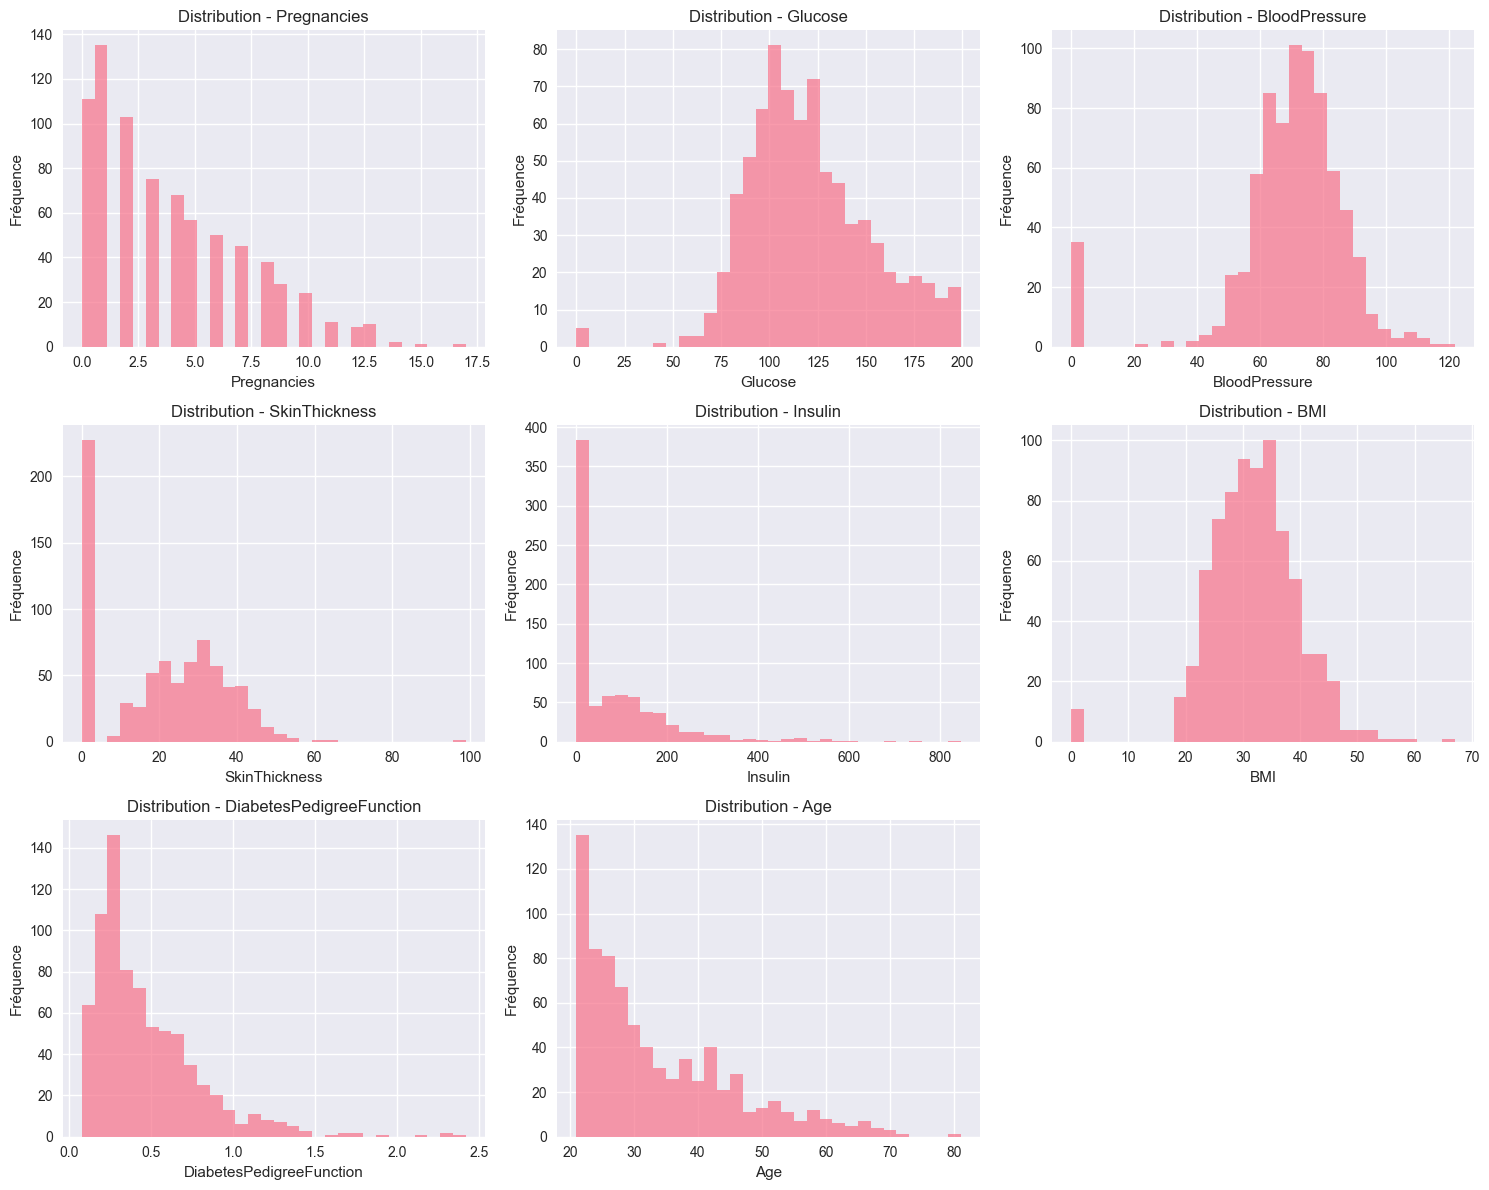

In [8]:
# ================================================================================================
# IMPORTATION DES BIBLIOTHÈQUES
# ================================================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
import joblib
from datetime import datetime

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, 
                           accuracy_score, precision_score, recall_score, f1_score)
from sklearn.metrics import silhouette_score


# Gestion du déséquilibre des classes
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# Importation des modules 
from data_loading import load_and_explore_data
from exploratory_analysis import perform_eda
from data_preprocessing import preprocess_data
from clustering_kmeans import perform_clustering
from cluster_analysis import analyze_clusters
from classification_preparation import prepare_classification_data
from model_training import train_classification_models
from model_evaluation import evaluate_models
from hyperparameter_optimization import optimize_best_model
from explainability import explain_model
from model_deployment import save_final_model
from prediction_function import predict_diabetes_risk


# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


def run_complete_pipeline(data_path='../data/diabete.csv'):
    """
    MODULE 13: Pipeline principal qui exécute tout le processus
    
    Cette fonction orchestre l'exécution de tous les modules.
    """
    print("🚀 DÉMARRAGE DU PIPELINE COMPLET")
    print("="*80)
    
    try:
        # MODULE 1: Chargement des données
        df = load_and_explore_data(data_path)
        if df is None:
            return None
        
        # MODULE 2: Analyse exploratoire
        correlation_matrix = perform_eda(df)
        
        # MODULE 3: Prétraitement
        df_processed, df_scaled, scaler_clustering, clustering_features = preprocess_data(df)
        
        # MODULE 4: Clustering
        kmeans_model, cluster_labels, optimal_k = perform_clustering(df_scaled)
        
        # MODULE 5: Analyse des clusters
        df_with_clusters, pca, high_risk_cluster = analyze_clusters(
            df_processed, df_scaled, cluster_labels, clustering_features
        )
        
        # MODULE 6: Préparation classification
        X_train, X_test, y_train, y_test = prepare_classification_data(
            df_with_clusters, clustering_features
        )
        
        # MODULE 7: Entraînement des modèles
        model_results, trained_models, scaler_clf = train_classification_models(
            X_train, X_test, y_train, y_test
        )
        
        # MODULE 8: Évaluation
        best_model_name, comparison_df = evaluate_models(model_results, y_test)
        
        # MODULE 9: Optimisation
        optimized_model, scaler_opt = optimize_best_model(
            best_model_name, trained_models, X_train, y_train
        )
        
        # MODULE 10: Explicabilité
        feature_importance = explain_model(
            optimized_model, X_train, X_test, y_test, 
            clustering_features, best_model_name
        )
        
        # MODULE 11: Sauvegarde finale
        final_scaler = scaler_opt if scaler_opt is not None else scaler_clf
        model_package = save_final_model(
            optimized_model, final_scaler, scaler_clustering,
            clustering_features, high_risk_cluster, best_model_name
        )
        
        print("\n" + "="*80)
        print("🎉 PIPELINE TERMINÉ AVEC SUCCÈS!")
        print("="*80)
        print(f"🏆 Meilleur modèle: {best_model_name}")
        print(f"📊 Nombre de clusters optimaux: {optimal_k}")
        print(f"🔴 Cluster haut risque: {high_risk_cluster}")
        print(f"💾 Modèle sauvegardé: diabetes_risk_prediction_model_v1.0.pkl")
        print("📁 Graphiques disponibles dans: plots/")
        print("🤖 Modèles disponibles dans: models/")
        
        return model_package
        
    except Exception as e:
        print(f"❌ ERREUR DANS LE PIPELINE: {e}")
        return None

# ================================================================================================
# FONCTION DE DÉMONSTRATION
# ================================================================================================

def demo_prediction():
    """
    Fonction de démonstration des prédictions
    """
    print("\n🎭 DÉMONSTRATION DES PRÉDICTIONS")
    print("-" * 60)
    
    # Exemples de patients
    patients = [
        {"name": "Patient A (Faible risque)", "glucose": 85, "bmi": 23, "age": 25, "pedigree": 0.2},
        {"name": "Patient B (Risque modéré)", "glucose": 120, "bmi": 28, "age": 45, "pedigree": 0.5},
        {"name": "Patient C (Haut risque)", "glucose": 180, "bmi": 35, "age": 60, "pedigree": 0.8}
    ]
    
    for patient in patients:
        print(f"\n👤 {patient['name']}")
        result = predict_diabetes_risk(
            patient['glucose'], patient['bmi'], 
            patient['age'], patient['pedigree']
        )
        
        if 'error' not in result:
            print(f"   🎯 Prédiction: {result['risk_level']}")
            print(f"   📊 Confiance: {result['confidence']:.1f}%")
            print(f"   🔴 Probabilité haut risque: {result['probability_high_risk']:.1f}%")
        else:
            print(f"   ❌ {result['error']}")

# ================================================================================================
# POINT D'ENTRÉE PRINCIPAL
# ================================================================================================

if __name__ == "__main__":
    # Exécution du pipeline complet
    model_package = run_complete_pipeline()
    
    if model_package is not None:
        # Démonstration des prédictions
        demo_prediction()
        
        print("\n" + "="*80)
        print("📚 POUR UTILISER LE MODÈLE:")
        print("="*80)
        print("# Exemple d'utilisation:")
        print("result = predict_diabetes_risk(glucose=140, bmi=32, age=50, diabetes_pedigree=0.6)")
        print("print(result)")
        print("\n💡 Le système est maintenant prêt pour la production!")
    else:
        print("❌ Échec du pipeline. Veuillez vérifier les données d'entrée.")

In [9]:
result = predict_diabetes_risk(glucose=140, bmi=32, age=50, diabetes_pedigree=0.6)
print(result)

{'error': "Erreur lors de la prédiction: [Errno 2] No such file or directory: 'models/diabetes_risk_prediction_model_v1.0.pkl'"}
